<a href="https://colab.research.google.com/github/carloscifuentesingsoft1560-cyber/Algebra_Lineal_machine_lerning2/blob/main/decision_tree_ramdom_forest_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importar las librerias principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Cargamos el data set
df_car = pd.read_csv('/content/car_evaluation.csv', header=None)


In [3]:
#Visualización del data frame
df_car.head(10)

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [4]:
# Analiz<amos el shape del objeto
print(df_car.shape)

(1728, 7)


In [5]:
# Como podemos observar vamos a renombrar las columnas de manera correcta
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df_car.columns = col_names

In [6]:
# Vericar transformación
df_car.head(10)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [7]:
# Visualizamos los tipos de datos
df_car.dtypes

,0
buying,object
maint,object
doors,object
persons,object
lug_boot,object
safety,object
class,object


In [8]:
# Exploremos un poco mas la variable target
df_car['class'].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


In [15]:
# vericamos valores missing
df_car.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [9]:
# separamos en X e y
X = df_car.drop(['class'], axis=1)
y = df_car['class']


In [16]:
# Importamos las librerias necesarias para la creacion del modelo
from sklearn.model_selection import train_test_split
# 30% para test y 70% para train

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [17]:
# Veamos que obtivimos
x_train.shape, x_test.shape

((1209, 6), (519, 6))

In [19]:
y_train.shape, y_test.shape

((1209,), (519,))

In [20]:
x_train.head(10)

,buying,maint,doors,persons,lug_boot,safety
1178,med,med,5more,4,big,high
585,high,high,3,more,small,low
1552,low,med,3,4,med,med
1169,med,med,5more,2,big,high
1033,med,high,4,2,big,med
888,med,vhigh,2,more,big,low
1001,med,high,3,2,small,high
327,vhigh,low,2,2,med,low
879,med,vhigh,2,4,big,low
1217,med,low,3,2,small,high


In [22]:
x_train.dtypes

,0
buying,object
maint,object
doors,object
persons,object
lug_boot,object
safety,object


In [24]:
%pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.5 MB/s eta 0:00:00


In [26]:
# importante: todos nuestros tipos de datos son object, realizamos una trasnformación

import category_encoders as ce #pip installa category_encoders

encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])

x_train = encoder.fit_transform(x_train)
x_test = encoder.transform(x_test)

In [27]:
#Verificamos transformación
x_train.head(10)

,buying,maint,doors,persons,lug_boot,safety
1178,1,1,1,1,1,1
585,2,2,2,2,2,2
1552,3,1,2,1,3,3
1169,1,1,1,3,1,1
1033,1,2,3,3,1,3
888,1,3,4,2,1,2
1001,1,2,2,3,2,1
327,4,4,4,3,3,2
879,1,3,4,1,1,2
1217,1,4,2,3,2,1


In [29]:
#importamos arbol de desicion
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=2, random_state=0)


In [30]:
#Entrenamiento
tree.fit(x_train, y_train)


DecisionTreeClassifier(max_depth=2, random_state=0)

In [31]:
# Calculo de as predicciones en Train y Test

y_train_pred_tree = tree.predict(x_train)
y_test_pred_tree = tree.predict(x_test)

In [33]:
# Calculo de metricas
from sklearn.metrics import accuracy_score
#Calculo el accuracy en train
train_accuracy_tree = accuracy_score(y_train, y_train_pred_tree)
#Calculo el accuracy en test
test_accuracy_tree = accuracy_score(y_test, y_test_pred_tree)

In [34]:
print('Accuracy en train:', train_accuracy_tree)
print('Accuracy en test:', test_accuracy_tree)

Accuracy en train: 0.7733664185277088
Accuracy en test: 0.7591522157996147


/tmp/ipykernel_859/505515579.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columns, y=importances, palette='bright', saturation= 2.0, edgecolor ='black', linewidth=2)


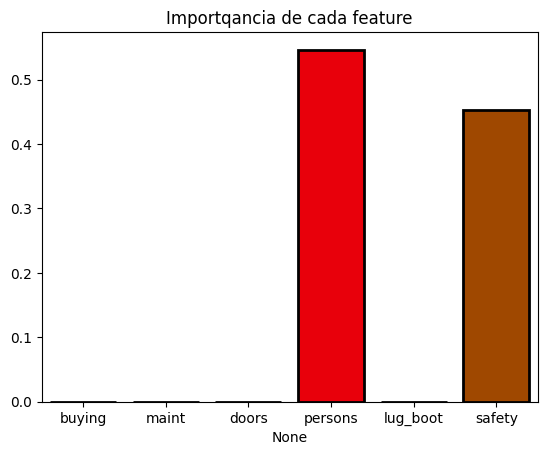

In [37]:
#verificamos el feature importance
import seaborn as sns
importances = tree.feature_importances_
columns = X.columns
sns.barplot(x=columns, y=importances, palette='bright', saturation= 2.0, edgecolor ='black', linewidth=2)
plt.title('Importqancia de cada feature')
plt.show()


In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [43]:
# Cambia tus líneas por estas:
train_precision_tree = precision_score(y_train, y_train_pred_tree, average='weighted')
test_precision_tree = precision_score(y_test, y_test_pred_tree, average='weighted')

train_recall_tree = recall_score(y_train, y_train_pred_tree, average='weighted')
test_recall_tree = recall_score(y_test, y_test_pred_tree, average='weighted')

# Cambia tus líneas por estas:
train_f1_tree = f1_score(y_train, y_train_pred_tree, average='weighted')
test_f1_tree = f1_score(y_test, y_test_pred_tree, average='weighted')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
print('Presition en train:', train_precision_tree)
print('Presition en test:', test_precision_tree)

print('Recall en train:', train_recall_tree)
print('Recall en test:', test_recall_tree)

print('f1 en train:', train_f1_tree)
print('f1 en test:', test_f1_tree)

print('Accuracy en train:', train_accuracy_tree)
print('Accuracy en test:', test_accuracy_tree)

Presition en train: 0.7117558482322751
Presition en test: 0.6865039980476906
Recall en train: 0.7733664185277088
Recall en test: 0.7591522157996147
f1 en train: 0.7411668940138306
f1 en test: 0.7201251812035838
Accuracy en train: 0.7733664185277088
Accuracy en test: 0.7591522157996147


/tmp/ipykernel_859/1616241814.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columns, y=importances, palette='bright', saturation= 2.0, edgecolor ='black', linewidth=2)


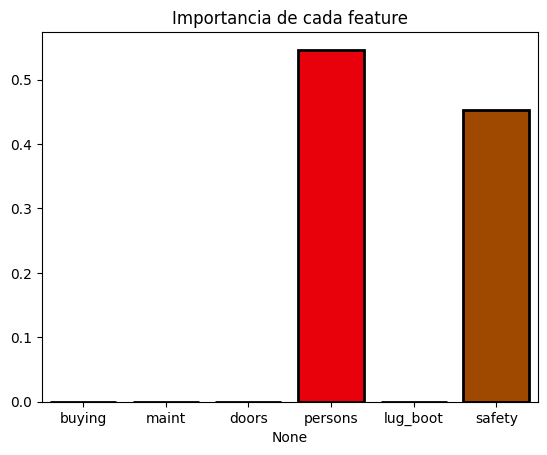

In [47]:
importances = tree.feature_importances_
columns = X.columns
sns.barplot(x=columns, y=importances, palette='bright', saturation= 2.0, edgecolor ='black', linewidth=2)
plt.title('Importancia de cada feature')
plt.show()